In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import rasterio
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
BASE_PATH = "/content/drive/MyDrive/MARIDA"
PATCH_PATH = BASE_PATH + "/patches"

MODEL_PATH = "/content/drive/MyDrive/marine_debris_unet_v3.keras"  # NEW NAME

In [ ]:
def load_patch_by_name(patch_name):
    patch_name = patch_name.replace(".tif", "")
    full_name = "S2_" + patch_name

    for scene in os.listdir(PATCH_PATH):
        scene_path = os.path.join(PATCH_PATH, scene)

        img_path  = os.path.join(scene_path, full_name + ".tif")
        mask_path = os.path.join(scene_path, full_name + "_cl.tif")

        if os.path.exists(img_path) and os.path.exists(mask_path):
            with rasterio.open(img_path) as src:
                img = src.read().astype(np.float32)

            with rasterio.open(mask_path) as src:
                mask = src.read(1)

            return img, mask

    return None, None

In [ ]:
DEBRIS_CLASS = 1

def convert_to_binary(mask):
    return (mask == DEBRIS_CLASS).astype(np.float32)

def compute_indices(img):
    img = img / 10000.0

    blue  = img[1]
    green = img[2]
    red   = img[3]
    nir   = img[7]
    swir1 = img[10]
    red_edge2 = img[5]

    ndvi = (nir - red) / (nir + red + 1e-6)
    ndwi = (green - nir) / (green + nir + 1e-6)
    fdi  = nir - (red_edge2 + (swir1 - red_edge2))

    features = np.stack([red, green, blue, nir, ndvi, ndwi, fdi], axis=-1)

    # STRONG NORMALIZATION (IMPORTANT)
    features = (features - np.mean(features)) / (np.std(features) + 1e-6)

    return features.astype(np.float32)

In [ ]:
all_patches = []

for scene in os.listdir(PATCH_PATH):
    for file in os.listdir(os.path.join(PATCH_PATH, scene)):
        if file.endswith(".tif") and not file.endswith("_cl.tif"):
            name = file.replace("S2_", "").replace(".tif", "")
            all_patches.append(name)

In [ ]:
def patch_has_debris(name):
    _, mask = load_patch_by_name(name)
    if mask is None:
        return False
    return np.sum(mask == DEBRIS_CLASS) > 0

debris_patches = []
empty_patches = []

for name in tqdm(all_patches):
    if patch_has_debris(name):
        debris_patches.append(name)
    else:
        empty_patches.append(name)

random.shuffle(debris_patches)
random.shuffle(empty_patches)

split_d = int(0.7 * len(debris_patches))
split_e = int(0.7 * len(empty_patches))

train_list = debris_patches[:split_d] + empty_patches[:split_e]
val_list   = debris_patches[split_d:] + empty_patches[split_e:]

# STRONG OVERSAMPLING
train_list = train_list + debris_patches[:split_d] * 7
random.shuffle(train_list)

100%|██████████| 2779/2779 [09:36<00:00,  4.82it/s]


In [ ]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, patch_list, batch_size=4, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.patch_list = patch_list
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __len__(self):
        return int(np.ceil(len(self.patch_list) / self.batch_size))

    def __getitem__(self, index):
        batch = self.patch_list[index*self.batch_size:(index+1)*self.batch_size]

        X, y = [], []

        for name in batch:
            img, mask = load_patch_by_name(name)
            if img is None:
                continue

            f = compute_indices(img)
            m = convert_to_binary(mask)[..., np.newaxis]

            if np.isfinite(f).all():
                X.append(f)
                y.append(m)

        if len(X) == 0:
            return self.__getitem__(random.randint(0, len(self)-1))

        return np.array(X), np.array(y)

train_gen = DataGenerator(train_list)
val_gen   = DataGenerator(val_list, shuffle=False)

In [ ]:
bce = tf.keras.losses.BinaryCrossentropy()

def dice_loss(y_true, y_pred):
    inter = tf.reduce_sum(y_true * y_pred)
    denom = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2 * inter + 1e-6) / (denom + 1e-6)

def focal_loss(y_true, y_pred, gamma=3):   # stronger
    y_pred = tf.clip_by_value(y_pred, 1e-6, 1-1e-6)
    pt = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
    return tf.reduce_mean((1-pt)**gamma * -tf.math.log(pt))

def weighted_bce(y_true, y_pred):
    weights = y_true * 20 + 1   # BIG BOOST
    return tf.reduce_mean(weights * bce(y_true, y_pred))

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred) + focal_loss(y_true, y_pred)

In [ ]:
TH = 0.15
def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > TH, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + 1e-6) / (union + 1e-6))
def dice_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > TH, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])
    return tf.reduce_mean((2*inter + 1e-6) / (denom + 1e-6))
def precision_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > TH, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fp = tf.reduce_sum((1-y_true) * y_pred, axis=[1,2,3])
    return tf.reduce_mean((tp+1e-6)/(tp+fp+1e-6))
def recall_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > TH, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fn = tf.reduce_sum(y_true * (1-y_pred), axis=[1,2,3])
    return tf.reduce_mean((tp+1e-6)/(tp+fn+1e-6))
def f1_metric(y_true, y_pred):
    p = precision_metric(y_true, y_pred)
    r = recall_metric(y_true, y_pred)
    return 2*p*r/(p+r+1e-6)

In [ ]:
def build_unet(shape):
    i = tf.keras.layers.Input(shape)

    c1 = tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(i)
    c1 = tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(c2)

    u = tf.keras.layers.UpSampling2D()(c2)
    u = tf.keras.layers.concatenate([u,c1])

    c3 = tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(u)
    o  = tf.keras.layers.Conv2D(1,1,activation='sigmoid')(c3)

    return tf.keras.Model(i,o)

In [ ]:
model = build_unet((256,256,7))

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[iou_metric, dice_metric, precision_metric, recall_metric, f1_metric]
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_PATH,
    monitor='val_iou_metric',
    save_best_only=True,
    mode='max'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_iou_metric',
    patience=3,
    mode='max',
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

Epoch 1/25
943/943 ━━━━━━━━━━━━━━━━━━━━ 1126s 1s/step - dice_metric: 0.1166 - f1_metric: 0.2060 - iou_metric: 0.1165 - loss: 1.0186 - precision_metric: 0.4919 - recall_metric: 0.2830 - val_dice_metric: 0.5271 - val_f1_metric: 0.5740 - val_iou_metric: 0.5271 - val_loss: 1.0018 - val_precision_metric: 0.6415 - val_recall_metric: 0.8565 - learning_rate: 1.0000e-04
Epoch 2/25
943/943 ━━━━━━━━━━━━━━━━━━━━ 1083s 1s/step - dice_metric: 0.2428 - f1_metric: 0.3727 - iou_metric: 0.1999 - loss: 0.8501 - precision_metric: 0.4637 - recall_metric: 0.5201 - val_dice_metric: 0.4460 - val_f1_metric: 0.5156 - val_iou_metric: 0.4307 - val_loss: 0.9140 - val_precision_metric: 0.4692 - val_recall_metric: 0.9281 - learning_rate: 1.0000e-04
Epoch 3/25
943/943 ━━━━━━━━━━━━━━━━━━━━ 1019s 1s/step - dice_metric: 0.3322 - f1_metric: 0.4462 - iou_metric: 0.2690 - loss: 0.7408 - precision_metric: 0.4566 - recall_metric: 0.6180 - val_dice_metric: 0.5241 - val_f1_metric: 0.5888 - val_iou_metric: 0.5085 - val_loss: 0.

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/marine_debris_unet_v3.keras",
    custom_objects={
        'combined_loss': combined_loss,
        'iou_metric': iou_metric,
        'dice_metric': dice_metric,
        'precision_metric': precision_metric,
        'recall_metric': recall_metric,
        'f1_metric': f1_metric
    }
)

print("Best model loaded!")

Best model loaded!


In [ ]:
TH = 0.15   # same as training

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[iou_metric, dice_metric, precision_metric, recall_metric, f1_metric]
)

In [ ]:
results = model.evaluate(val_gen)

print("\nFINAL RESULTS")
print("IoU      :", results[1])
print("Dice     :", results[2])
print("Precision:", results[3])
print("Recall   :", results[4])
print("F1 Score :", results[5])

209/209 ━━━━━━━━━━━━━━━━━━━━ 60s 281ms/step - dice_metric: 0.6267 - f1_metric: 0.6855 - iou_metric: 0.6119 - loss: 0.8987 - precision_metric: 0.6379 - recall_metric: 0.9416

FINAL RESULTS
IoU      : 0.6118800044059753
Dice     : 0.6266749501228333
Precision: 0.6379196047782898
Recall   : 0.9416176676750183
F1 Score : 0.6855137348175049


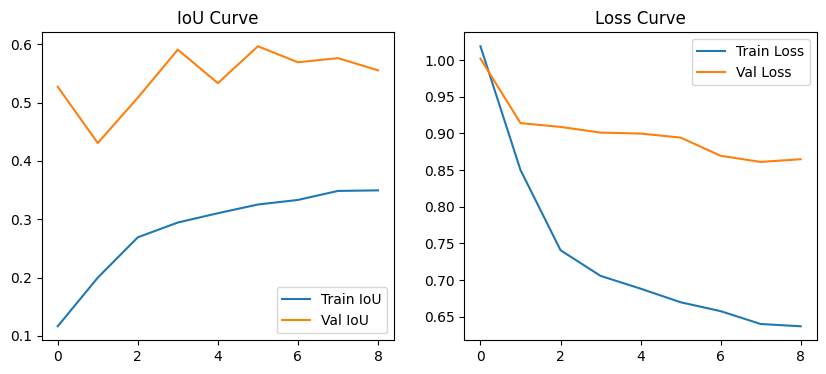

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# IoU
plt.subplot(1,2,1)
plt.plot(history.history['iou_metric'], label='Train IoU')
plt.plot(history.history['val_iou_metric'], label='Val IoU')
plt.legend()
plt.title("IoU Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

In [ ]:
X_batch, y_batch = val_gen[0]

In [ ]:
pred = model.predict(X_batch[0:1], verbose=0)[0]

print("Min:", np.min(pred))
print("Max:", np.max(pred))
print("Mean:", np.mean(pred))

Min: 4.681172e-30
Max: 0.9961716
Mean: 0.00012711764


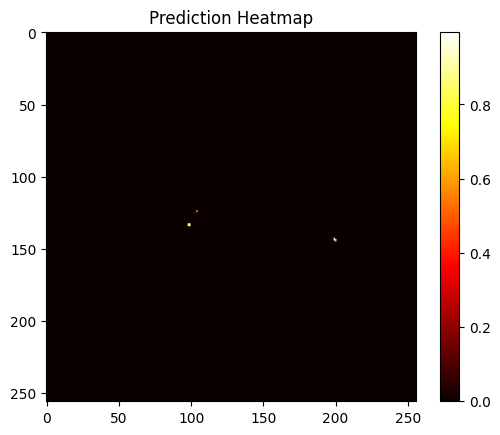

In [ ]:
plt.imshow(pred.squeeze(), cmap='hot')
plt.colorbar()
plt.title("Prediction Heatmap")
plt.show()

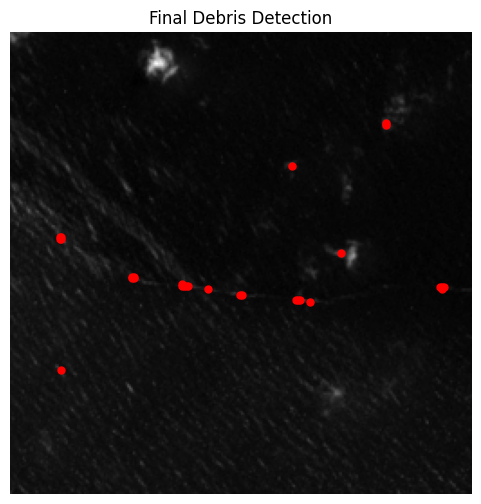

In [ ]:
TH = 0.15   # best for IoU + clarity

idx = 2
pred = model.predict(X_batch[idx:idx+1], verbose=0)[0]

mask = (pred.squeeze() > TH)

plt.figure(figsize=(6,6))

plt.imshow(X_batch[idx][:,:,0], cmap='gray')

plt.scatter(
    np.where(mask)[1],
    np.where(mask)[0],
    c='red',
    s=25
)

plt.title("Final Debris Detection")
plt.axis('off')
plt.show()

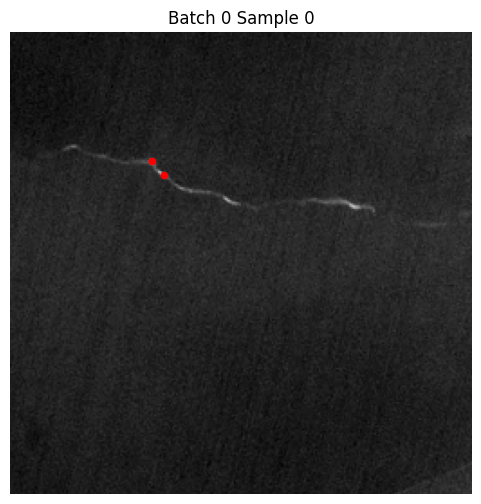

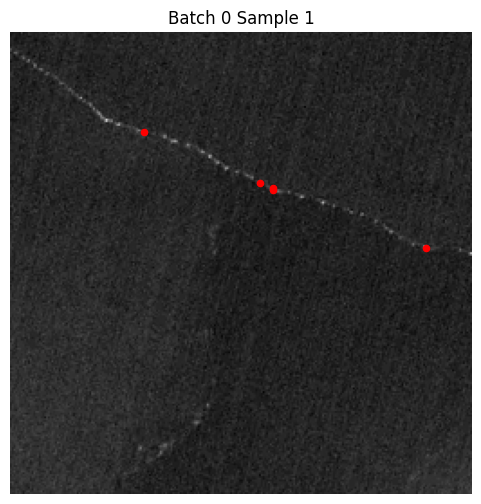

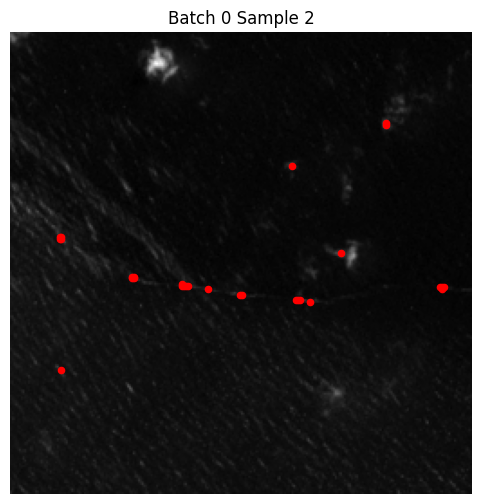

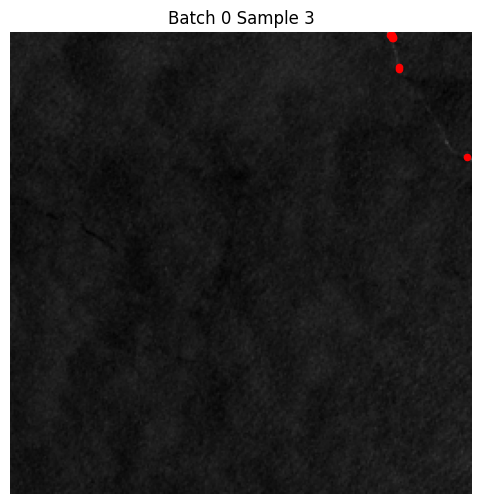

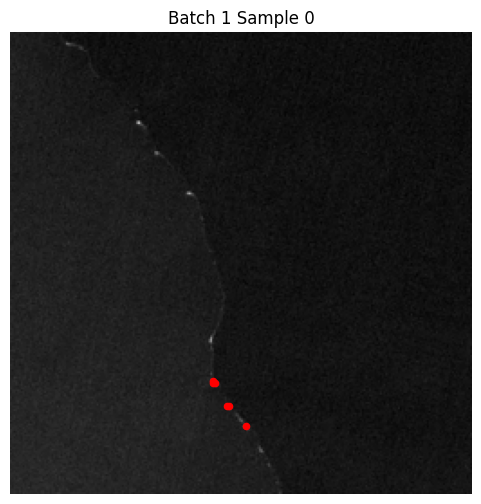

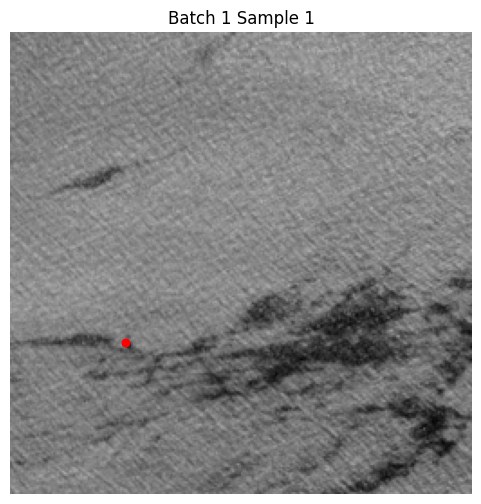

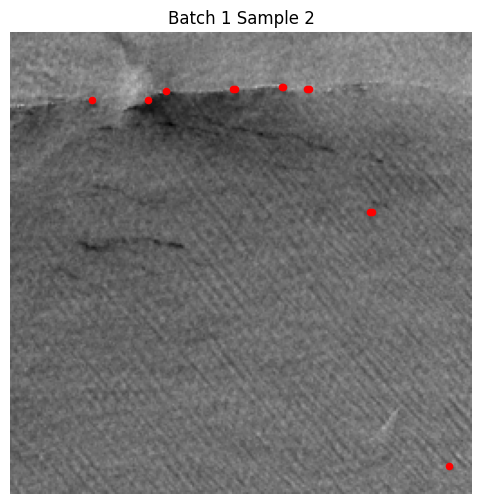

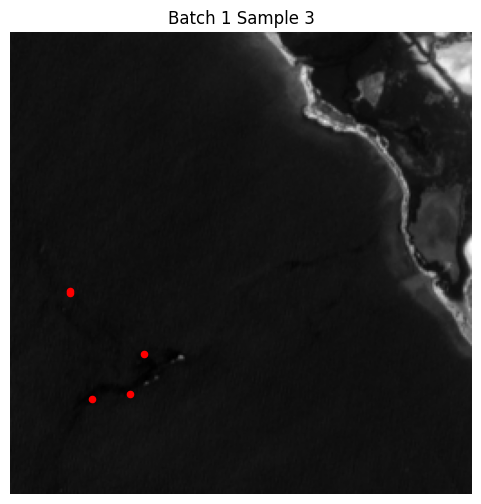

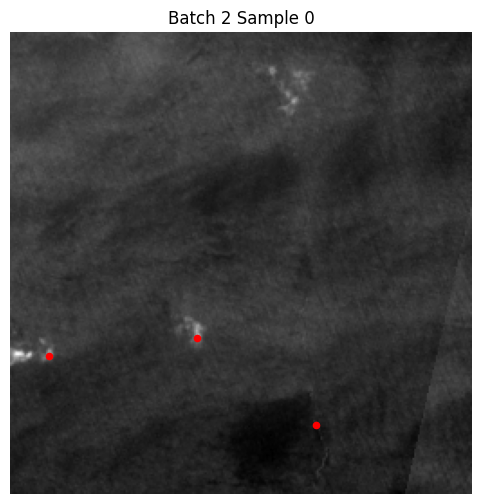

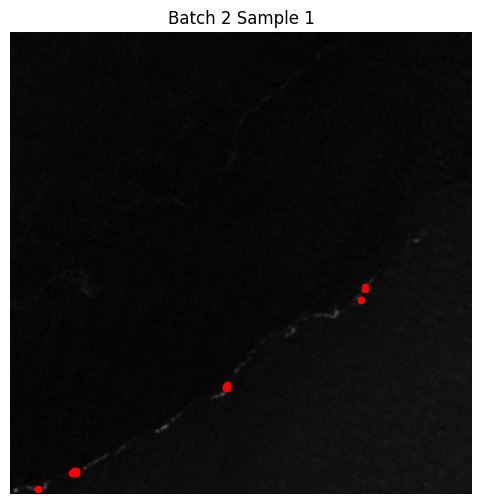

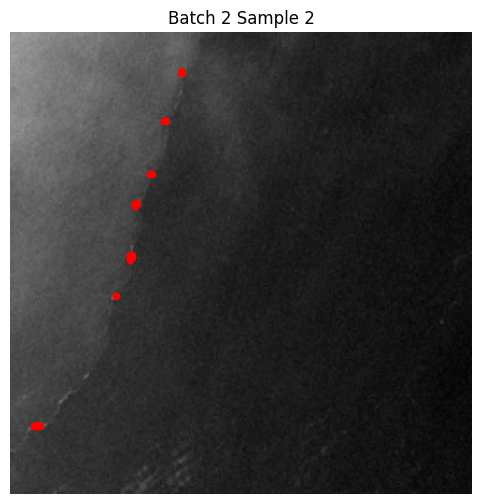

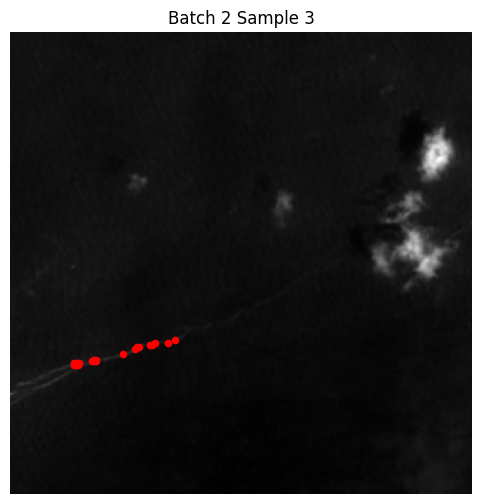

In [ ]:
TH = 0.15

for batch_idx in range(3):
    X_batch, y_batch = val_gen[batch_idx]

    for i in range(len(X_batch)):
        if np.sum(y_batch[i]) > 0:

            pred = model.predict(X_batch[i:i+1], verbose=0)[0]
            mask = (pred.squeeze() > TH)

            plt.figure(figsize=(6,6))
            plt.imshow(X_batch[i][:,:,0], cmap='gray')

            plt.scatter(
                np.where(mask)[1],
                np.where(mask)[0],
                c='red',
                s=20
            )

            plt.title(f"Batch {batch_idx} Sample {i}")
            plt.axis('off')
            plt.show()

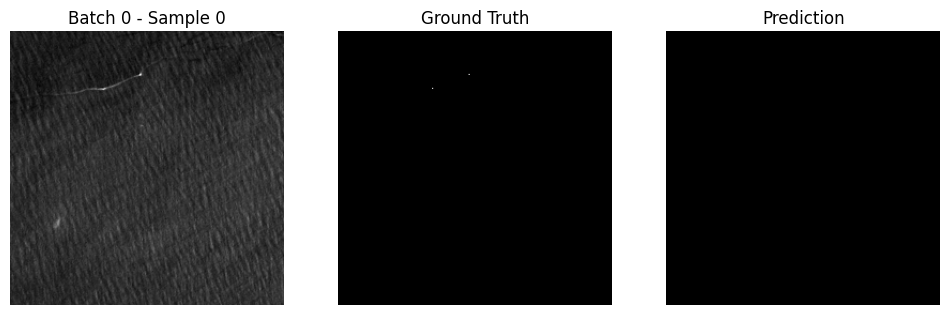

Batch 0, Sample 0
Max: 0.00048036795
Mean: 1.1213498e-08
----------------------------------------


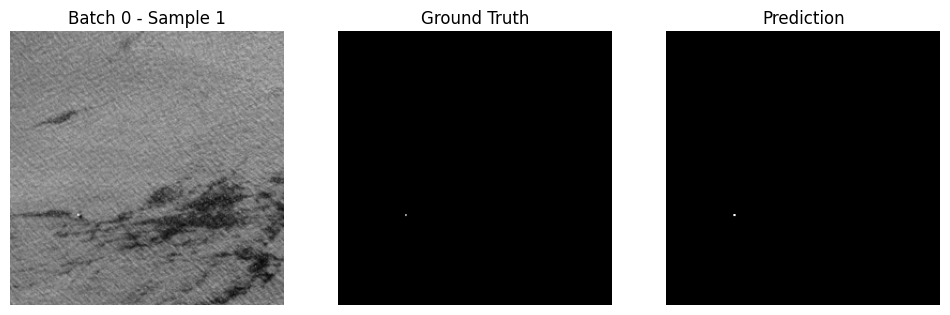

Batch 0, Sample 1
Max: 0.99992603
Mean: 6.098585e-05
----------------------------------------


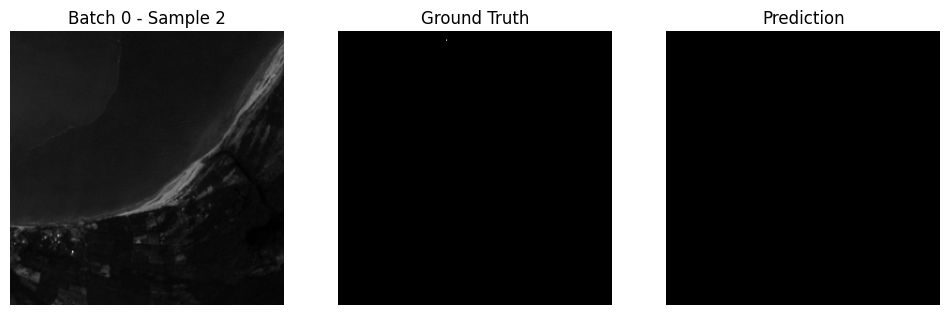

Batch 0, Sample 2
Max: 0.0028701753
Mean: 4.913585e-07
----------------------------------------


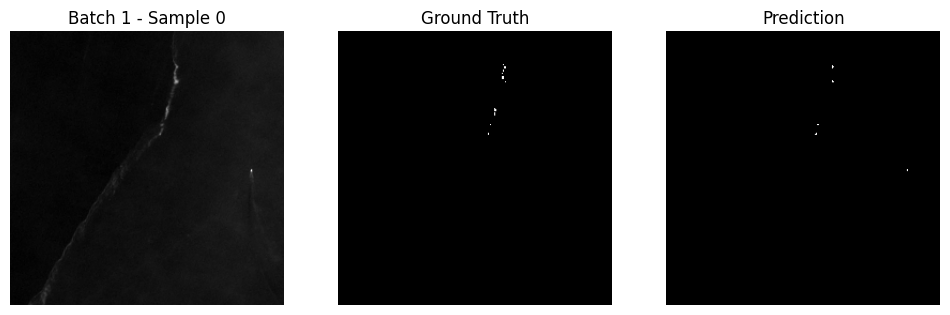

Batch 1, Sample 0
Max: 0.9997989
Mean: 0.00020496198
----------------------------------------


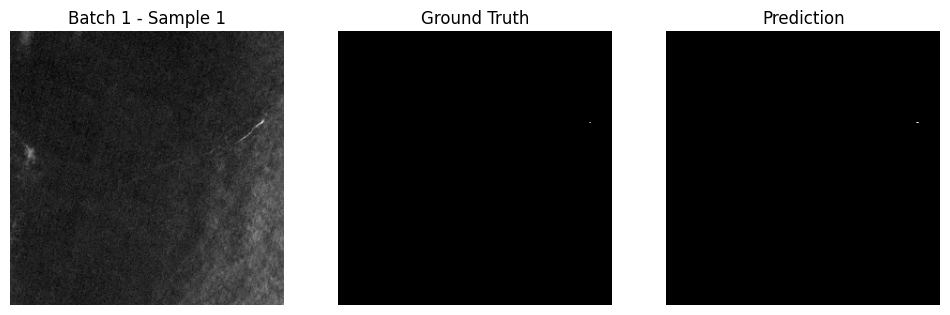

Batch 1, Sample 1
Max: 0.8200115
Mean: 2.2404576e-05
----------------------------------------


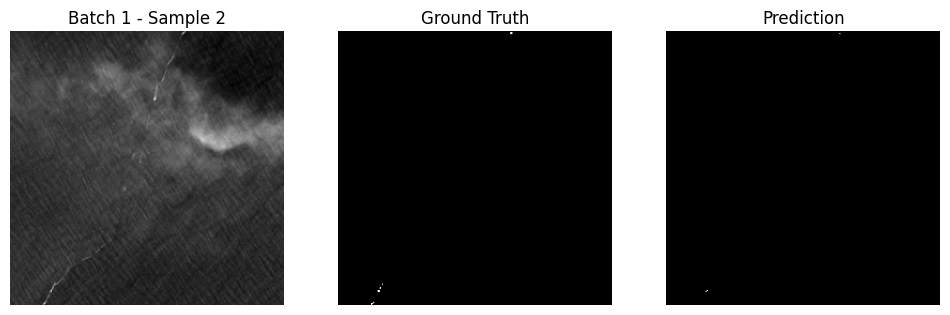

Batch 1, Sample 2
Max: 0.9803829
Mean: 3.9410348e-05
----------------------------------------


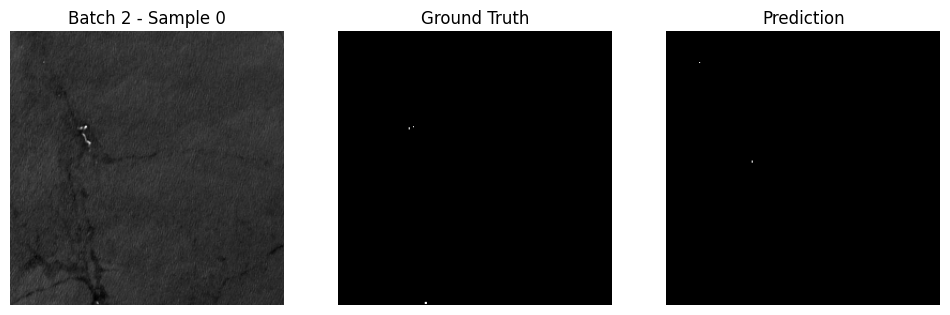

Batch 2, Sample 0
Max: 0.606158
Mean: 2.0928877e-05
----------------------------------------


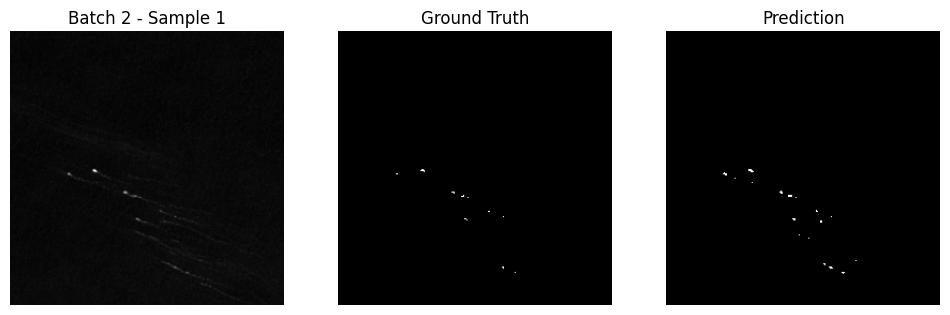

Batch 2, Sample 1
Max: 0.99994236
Mean: 0.00076061965
----------------------------------------


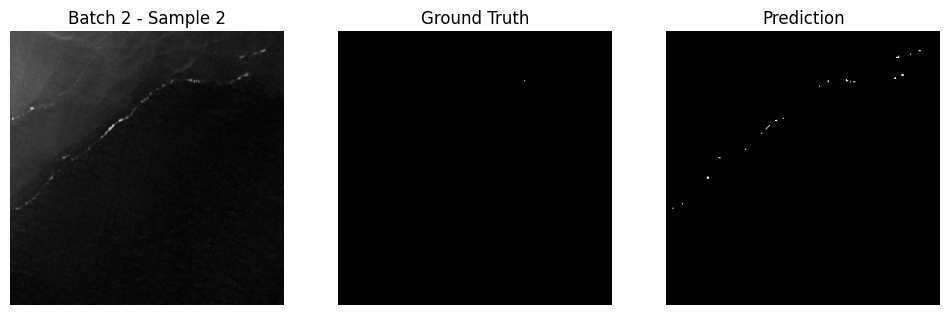

Batch 2, Sample 2
Max: 0.9991463
Mean: 0.00041960715
----------------------------------------


In [ ]:
TH = 0.15

num_batches = min(3, len(val_gen))

for b in range(num_batches):
    X_batch, y_batch = val_gen[b]

    num_samples = min(3, len(X_batch))

    for i in range(num_samples):
        pred = model.predict(X_batch[i:i+1], verbose=0)[0]
        mask = pred.squeeze() > TH

        plt.figure(figsize=(12,4))

        # Input
        plt.subplot(1,3,1)
        plt.imshow(X_batch[i][:,:,0], cmap='gray')
        plt.title(f"Batch {b} - Sample {i}")
        plt.axis('off')

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(y_batch[i].squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        # Prediction
        plt.subplot(1,3,3)
        plt.imshow(mask, cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

        plt.show()

        # print stats
        print(f"Batch {b}, Sample {i}")
        print("Max:", np.max(pred))
        print("Mean:", np.mean(pred))
        print("-"*40)